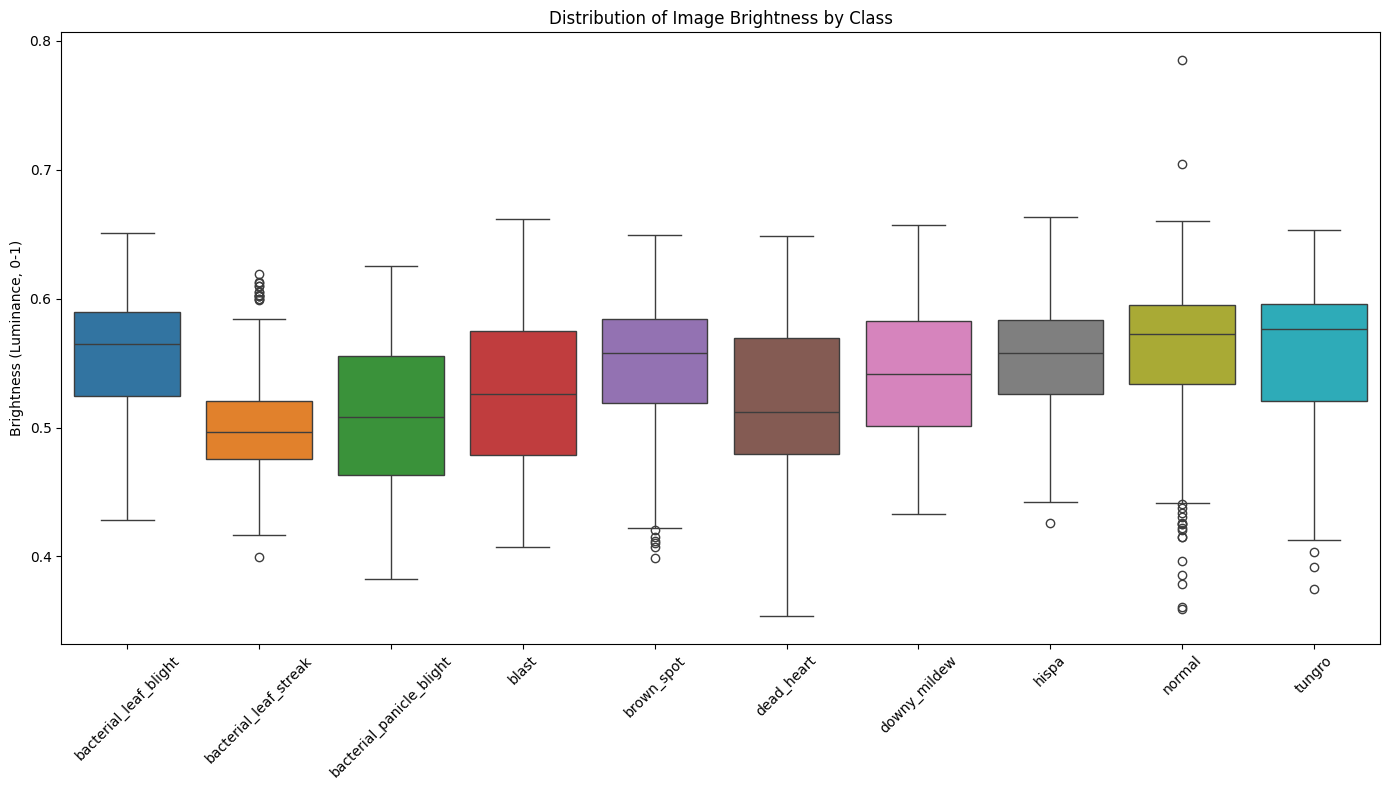

In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# Weighted Luminance
train_images_dir = "train_images"
class_brightness = {}

for folder in os.listdir(train_images_dir):
    folder_path = os.path.join(train_images_dir, folder)
    if not os.path.isdir(folder_path):
        continue
    
    brightness_values = []
    
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if not filename.lower().endswith('.jpg'):
            continue
        
        try:
            with Image.open(file_path) as img:
                img = img.convert("RGB")
                img_array = np.array(img) / 255.0  # Normalize to 0-1
                
                # Calculate luminance (perceived brightness)
                # Using standard coefficients: 0.2126*R + 0.7152*G + 0.0722*B
                luminance = 0.2126 * img_array[:,:,0] + 0.7152 * img_array[:,:,1] + 0.0722 * img_array[:,:,2]
                avg_brightness = np.mean(luminance)
                brightness_values.append(avg_brightness)
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
            
    if brightness_values:
        class_brightness[folder] = brightness_values

# Create boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(data=[class_brightness[cls] for cls in sorted(class_brightness.keys())])
plt.xticks(range(len(class_brightness)), sorted(class_brightness.keys()), rotation=45)
plt.title('Distribution of Image Brightness by Class')
plt.ylabel('Brightness (Luminance, 0-1)')
plt.tight_layout()
plt.savefig('class_brightness_boxplot.png')
plt.show()

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import matplotlib.colors as colors

# Path to the directory containing numpy arrays
train_hash_dir = "train_hash"
class_saturation = {}

for folder in os.listdir(train_hash_dir):
    folder_path = os.path.join(train_hash_dir, folder)
    if not os.path.isdir(folder_path):
        continue
    
    saturation_values = []
    
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if not filename.lower().endswith('.npy'):
            continue
        
        try:
            # Load the numpy array (in RGB format)
            img_array = np.load(file_path)
            
            # Normalize if needed (if not already normalized)
            if img_array.max() > 1.0:
                img_array = img_array / 255.0
            
            # Convert RGB to HSV (no need to drop alpha channel since it's already RGB)
            hsv_array = colors.rgb_to_hsv(img_array)
            
            # Extract the saturation channel (index 1 in HSV)
            saturation = hsv_array[:,:,1]
            avg_saturation = np.mean(saturation)
            saturation_values.append(avg_saturation)
            
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
            
    if saturation_values:
        class_saturation[folder] = saturation_values

# Create boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(data=[class_saturation[cls] for cls in sorted(class_saturation.keys())])
plt.xticks(range(len(class_saturation)), sorted(class_saturation.keys()), rotation=45)
plt.title('Distribution of Image Saturation by Class (from .npy files)')
plt.ylabel('Saturation (0-1)')
plt.tight_layout()
plt.savefig('class_saturation_boxplot_from_npy.png')
plt.show()

Error processing train_hash\bacterial_leaf_blight\100023.npy: Last dimension of input array must be 3; shape (640, 480, 4) was found.
Error processing train_hash\bacterial_leaf_blight\100049.npy: Last dimension of input array must be 3; shape (640, 480, 4) was found.
Error processing train_hash\bacterial_leaf_blight\100126.npy: Last dimension of input array must be 3; shape (640, 480, 4) was found.
Error processing train_hash\bacterial_leaf_blight\100133.npy: Last dimension of input array must be 3; shape (640, 480, 4) was found.
Error processing train_hash\bacterial_leaf_blight\100148.npy: Last dimension of input array must be 3; shape (640, 480, 4) was found.
Error processing train_hash\bacterial_leaf_blight\100162.npy: Last dimension of input array must be 3; shape (640, 480, 4) was found.
Error processing train_hash\bacterial_leaf_blight\100169.npy: Last dimension of input array must be 3; shape (640, 480, 4) was found.
Error processing train_hash\bacterial_leaf_blight\100234.npy: 

KeyboardInterrupt: 